# Logistic Regression: Predict Customer Purchase from Age and Income

This notebook builds a simple logistic regression model to predict whether a customer will buy a product based on two features: age and income. It includes the required notebook sections: Problem Statement, Understanding of Dataset, Theory, Mathematical Representation, Diagram, Pseudocode, Expected Output, and Obtained Output.

The implementation also includes data cleaning, exploratory data analysis, feature scaling, feature engineering, and evaluation using standard classification metrics.

In [10]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import joblib

DATA_PATH = "customer_purchase.csv"
FEATURE_COLS = ["age", "income"]
TARGET_COL = "purchase"

if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 200
    age = np.random.randint(18, 65, n)
    income = np.random.randint(20000, 120000, n)

    score = 0.03 * age + 0.00005 * income + np.random.normal(0, 0.35, n)
    purchase = (score > 3.2).astype(int)

    df_sample = pd.DataFrame({"age": age, "income": income, TARGET_COL: purchase})
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Found existing customer_purchase.csv, will use it

First 5 rows of customer_purchase.csv:
   age  income  purchase
0   56   72733         1
1   46   85318         1
2   32  109474         1
3   60   43664         1
4   25   87172         1


## 1. Problem Statement

Create a logistic regression model to predict whether a customer will buy a product based on age and income.

## 2. Understanding of Dataset

Load the dataset and inspect the columns, shape, and summary statistics.

In [11]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe().T)

print("\nClass Distribution:")
print(df[TARGET_COL].value_counts())

DATASET OVERVIEW

First 10 rows:
   age  income  purchase
0   56   72733         1
1   46   85318         1
2   32  109474         1
3   60   43664         1
4   25   87172         1
5   38  105616         1
6   56  113264         1
7   36   46736         0
8   40  114209         1
9   28   20854         0

Dataset shape: (200, 3)
Samples: 200, Features: 3

Data types:
age         int64
income      int64
purchase    int64
dtype: object

Statistical Summary:
          count      mean           std      min      25%      50%      75%  \
age       200.0     41.57     13.715527     18.0     30.0     42.0     54.0   
income    200.0  67875.05  29256.652896  20301.0  42603.0  67228.0  92235.0   
purchase  200.0      0.77      0.421889      0.0      1.0      1.0      1.0   

               max  
age           64.0  
income    119713.0  
purchase       1.0  

Class Distribution:
purchase
1    154
0     46
Name: count, dtype: int64


## 3. Data Cleaning

Check for missing values, duplicates, and invalid values.

In [12]:
print("="*60)
print("DATA CLEANING")
print("="*60)

print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    df = df.dropna()

print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"× Removed {dupes} duplicate(s)")
else:
    print("✓ No duplicates found")

print("\n3. Invalid Values Check:")
invalid_age = (df["age"] < 0).sum()
invalid_income = (df["income"] < 0).sum()
invalid_purchase = (~df[TARGET_COL].isin([0, 1])).sum()
print(f"Invalid age values: {invalid_age}")
print(f"Invalid income values: {invalid_income}")
print(f"Invalid purchase values: {invalid_purchase}")

df = df[(df["age"] >= 0) & (df["income"] >= 0)]
df = df[df[TARGET_COL].isin([0, 1])].reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
Missing values per column:
age         0
income      0
purchase    0
dtype: int64
✓ No missing values found

2. Duplicate Rows Check:
Duplicate rows: 0
✓ No duplicates found

3. Invalid Values Check:
Invalid age values: 0
Invalid income values: 0
Invalid purchase values: 0

Dataset shape after cleaning: (200, 3)


## 4. Exploratory Data Analysis (EDA)

Visualize how age and income relate to purchase behavior.

EXPLORATORY DATA ANALYSIS


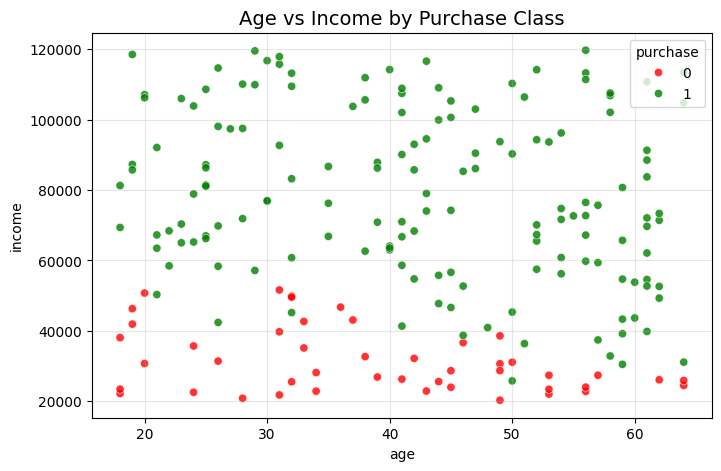

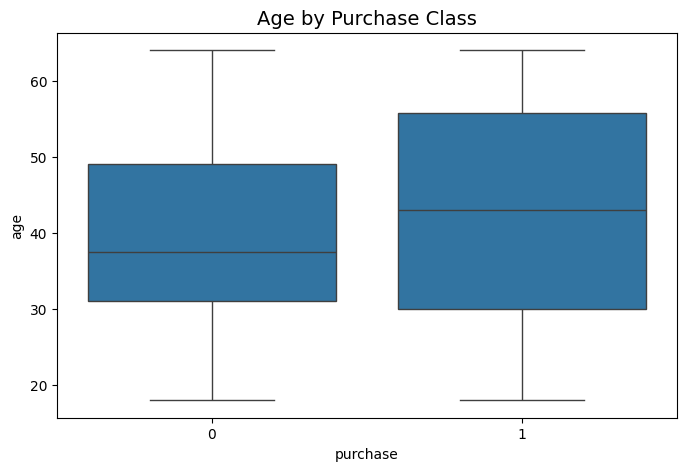

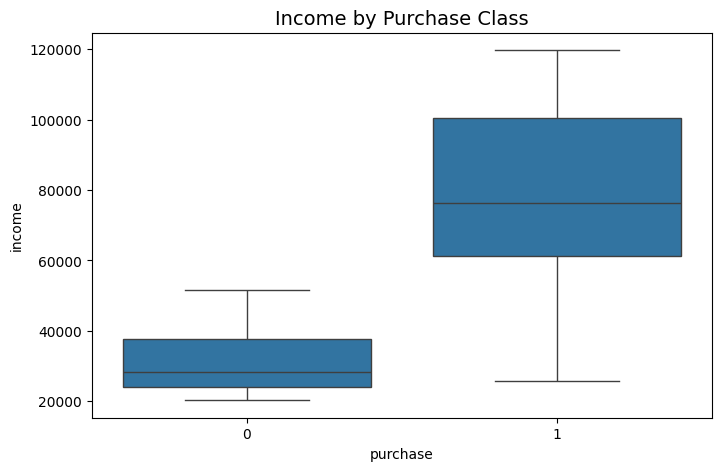


Correlation Matrix:
               age    income  purchase
age       1.000000 -0.088365  0.117430
income   -0.088365  1.000000  0.680987
purchase  0.117430  0.680987  1.000000


In [13]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="income", hue=TARGET_COL, palette={0: 'red', 1: 'green'}, alpha=0.8)
plt.title('Age vs Income by Purchase Class', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=TARGET_COL, y="age")
plt.title('Age by Purchase Class', fontsize=14)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=TARGET_COL, y="income")
plt.title('Income by Purchase Class', fontsize=14)
plt.show()

corr = df[["age", "income", TARGET_COL]].corr()
print("\nCorrelation Matrix:")
print(corr)

## 5. Feature Engineering & Scaling

Prepare features and scale them using StandardScaler.

In [ ]:
print("="*60)
print("FEATURE ENGINEERING & SCALING")
print("="*60)

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows of X:")
print(X[:5])
print("\nFirst 5 rows of scaled X:")
print(X_scaled[:5])

## 6. Theory

Logistic Regression is a classification algorithm that predicts class probabilities using the sigmoid function.

If the predicted probability is at least 0.5, the customer is classified as a buyer. Otherwise, the customer is classified as a non-buyer.

## 7. Mathematical Representation

Linear score: $z = eta_0 + eta_1x_1 + eta_2x_2$

Sigmoid probability: $p = rac{1}{1 + e^{-z}}$

Class prediction: buyer if $p e 0.5$, otherwise non-buyer.

## 8. Workflow Diagram

In [ ]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "Scale Features"),
    (0.3, 0.4, "Train Logistic\nRegression"),
    (0.55, 0.1, "Evaluate"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x - 0.08, step_y - 0.05), 0.12, 0.08, facecolor='lightgreen', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=9, fontweight='bold')

arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)), ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('Logistic Regression Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Pseudocode

```
1. Load customer purchase dataset
2. Clean data and remove invalid rows
3. Split features and target
4. Scale age and income
5. Split into training and test sets
6. Train logistic regression model
7. Predict purchase labels on test data
8. Evaluate with accuracy, precision, recall, F1-score, and confusion matrix
9. Save model and scaler
```

## 10. Train-Test Split and Model Training

In [ ]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Coefficients: {model.coef_[0]}")
print(f"Intercept: {model.intercept_[0]:.4f}")

## 11. Model Evaluation

In [ ]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Buy', 'Buy']))

print("Sample predictions:")
for i in range(min(8, len(y_test))):
    actual = 'Buy' if y_test[i] == 1 else 'Not Buy'
    predicted = 'Buy' if y_pred[i] == 1 else 'Not Buy'
    prob = y_prob[i]
    print(f"Actual: {actual:<8} | Predicted: {predicted:<8} | Buy Probability: {prob:.3f}")

## 12. Obtained Output

In [ ]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Buy', 'Buy'], yticklabels=['Not Buy', 'Buy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', alpha=0.8, edgecolors='black')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Income')
plt.title('Predicted Purchase Classes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

joblib.dump(model, '6_customer_purchase_model.joblib')
joblib.dump(scaler, '6_customer_purchase_scaler.joblib')

print("\n✓ Model and scaler saved successfully")
print("\nFinal Summary:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")